In [1]:
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../..").resolve()
MODEL_PATH = PROJECT_ROOT / "experiments" / "06_cross_view_mobilenetv2" / "best_mobilenetv2_crossview_finetuned.keras"
IMG_SIZE = (224, 224)
LABEL_NAMES = [
    "safe_driving", "texting_right", "phone_right", "texting_left", "phone_left",
    "adjusting_radio", "drinking", "reaching_behind", "hair_or_makeup", "talking_to_passenger",
]
CONFIDENCE_THRESHOLD = 0.40

IMAGE_PATH = r"D:\MSC_PROJECT\real_test_images\my_test_2.jpeg"  

model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

Model loaded: D:\MSC_PROJECT\experiments\06_cross_view_mobilenetv2\best_mobilenetv2_crossview_finetuned.keras


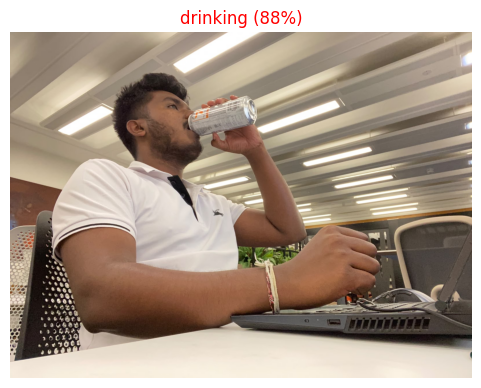

Predicted class: drinking
Confidence: 88.1%
Full class probabilities:
  drinking               88.1%
  texting_right          6.2%
  phone_right            5.6%
  hair_or_makeup         0.1%
  safe_driving           0.0%
  phone_left             0.0%
  talking_to_passenger   0.0%
  adjusting_radio        0.0%
  reaching_behind        0.0%
  texting_left           0.0%

Would trigger a distraction alert: YES


In [2]:
frame = cv2.imread(IMAGE_PATH)
if frame is None:
    raise RuntimeError(f"Could not read {IMAGE_PATH} - check the path")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
resized = tf.image.resize(frame_rgb, IMG_SIZE)
batch = tf.expand_dims(tf.cast(resized, tf.float32), axis=0)
probs = model.predict(batch, verbose=0)[0]

class_id = int(np.argmax(probs))
confidence = float(probs[class_id])
label = LABEL_NAMES[class_id]
is_distraction = class_id != 0 and confidence >= CONFIDENCE_THRESHOLD

plt.figure(figsize=(6, 4.5))
plt.imshow(frame_rgb)
plt.title(f"{label} ({confidence:.0%})", fontsize=12, color=("red" if is_distraction else "black"))
plt.axis("off")
plt.show()

print(f"Predicted class: {label}")
print(f"Confidence: {confidence:.1%}")
print(f"Full class probabilities:")
for name, p in sorted(zip(LABEL_NAMES, probs), key=lambda x: -x[1]):
    print(f"  {name:<22} {p:.1%}")
print()
print("Would trigger a distraction alert:" , "YES" if is_distraction else "NO")